# 2. Logistic Regression Baseline

First full-data Logistic Regression fit: stratified 80/20 split, `class_weight='balanced'`, confusion matrix, overall metrics, and coefficient interpretation.

In [2]:
import sys
from pathlib import Path

# Find the project root regardless of what VS Code / Jupyter set as the
# working directory (VS Code defaults notebooks to the workspace root,
# not the notebook's own folder, so ".." alone isn't reliable).
cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    recall_score,
)

from src.models import get_logistic_regression
from src.preprocessing import build_logreg_pipeline, load_data, stratified_split

df = load_data()


## 2.1  Why class_weight='balanced'?
Before fitting the final model: does an *unweighted* Logistic Regression just guess the majority class, or does it do something more subtle? (Notebook 01, section 1.2, showed pure majority-class guessing tops out at 49.9% this compares against a real fitted model instead).

In [3]:
X_train, X_test, y_train, y_test = stratified_split(df)

# Logistic Regression WITHOUT class_weight="balanced"
unweighted_model = LogisticRegression(max_iter=1000, random_state=42)
unweighted_pipe = build_logreg_pipeline(unweighted_model)
unweighted_pipe.fit(X_train, y_train)
y_pred_unweighted = unweighted_pipe.predict(X_test)

# Logistic Regression WITH class_weight="balanced" (used for the rest of this notebook)
balanced_pipe = build_logreg_pipeline(get_logistic_regression())
balanced_pipe.fit(X_train, y_train)
y_pred_balanced = balanced_pipe.predict(X_test)

comparison = pd.DataFrame({
    "Model": ["Unweighted", "class_weight='balanced'"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_unweighted),
        accuracy_score(y_test, y_pred_balanced),
    ],
    "Enrolled Recall": [
        recall_score(y_test, y_pred_unweighted, labels=["Enrolled"], average=None)[0],
        recall_score(y_test, y_pred_balanced, labels=["Enrolled"], average=None)[0],
    ],
})
display(comparison.round(3))

,Model,Accuracy,Enrolled Recall
0,Unweighted,0.771,0.390
1,class_weight='balanced',0.725,0.635


## 2.1 Model fit

In [4]:
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

pipe = balanced_pipe
y_pred = y_pred_balanced

print(classification_report(y_test, y_pred))


Train class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Test class balance:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64
              precision    recall  f1-score   support

     Dropout       0.82      0.68      0.74       284
    Enrolled       0.42      0.64      0.50       159
    Graduate       0.86      0.79      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



## 2.2 Confusion matrix

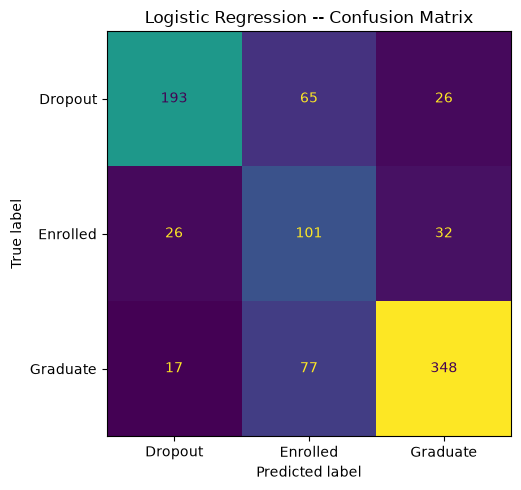

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Logistic Regression -- Confusion Matrix")
plt.tight_layout()
plt.show()


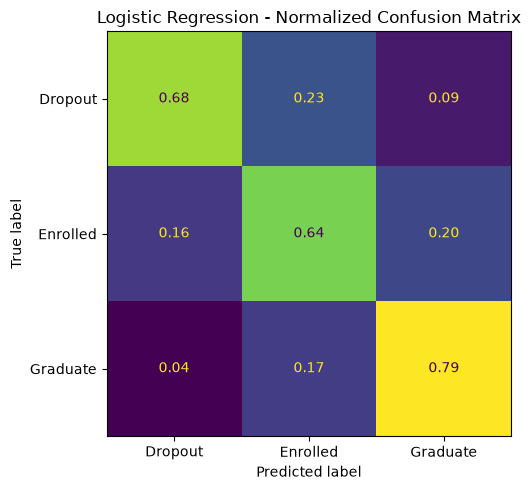

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true", values_format=".2f", colorbar=False, ax=ax
)
ax.set_title("Logistic Regression - Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


## 2.3 Overall performance metrics

In [7]:
logreg_accuracy = accuracy_score(y_test, y_pred)
logreg_macro_f1 = f1_score(y_test, y_pred, average="macro")
logreg_weighted_f1 = f1_score(y_test, y_pred, average="weighted")
logreg_macro_recall = recall_score(y_test, y_pred, average="macro")

print(f"Accuracy:     {logreg_accuracy:.3f}")
print(f"Macro F1:     {logreg_macro_f1:.3f}")
print(f"Weighted F1:  {logreg_weighted_f1:.3f}")
print(f"Macro Recall: {logreg_macro_recall:.3f}")


Accuracy:     0.725
Macro F1:     0.689
Weighted F1:  0.738
Macro Recall: 0.701


## 2.4 Coefficient interpretation

In [8]:
preprocessor = pipe.named_steps["preprocess"]
logreg_model = pipe.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame(
    logreg_model.coef_, columns=feature_names, index=logreg_model.classes_
)
coef_df.head()


,num__Application order,num__Previous qualification (grade),num__Admission grade,num__Age at enrollment,num__Curricular units 1st sem (credited),num__Curricular units 1st sem (enrolled),num__Curricular units 1st sem (evaluations),num__Curricular units 1st sem (approved),num__Curricular units 1st sem (grade),num__Curricular units 1st sem (without evaluations),...,cat__Father's occupation_194,cat__Father's occupation_195,bin__Daytime/evening attendance,bin__Displaced,bin__Educational special needs,bin__Debtor,bin__Tuition fees up to date,bin__Gender,bin__Scholarship holder,bin__International
Dropout,0.133287,0.015158,-0.005430,0.111113,0.159761,0.295679,-0.036332,-0.860635,0.087149,-0.078734,...,0.048904,-0.005002,0.151980,0.225685,0.095404,0.420087,-1.833524,0.212413,-0.182148,-0.190383
Enrolled,-0.132296,-0.033930,-0.056945,-0.018447,-0.024798,0.253876,0.194659,-0.424058,-0.081950,0.063416,...,-0.419082,-0.205185,-0.049833,-0.104617,0.002817,0.283711,0.245545,-0.093482,-0.286323,0.195478
Graduate,-0.000992,0.018772,0.062375,-0.092667,-0.134963,-0.549554,-0.158327,1.284694,-0.005199,0.015317,...,0.370178,0.210187,-0.102146,-0.121068,-0.098221,-0.703798,1.587979,-0.118931,0.468471,-0.005095


In [9]:
dropout_coef = coef_df.loc["Dropout"].sort_values()

print("Most negative coefficients:")
display(dropout_coef.head(10))

print("\nMost positive coefficients:")
display(dropout_coef.tail(10))


Most negative coefficients:


bin__Tuition fees up to date               -1.833524
num__Curricular units 2nd sem (approved)   -1.656041
cat__Mother's occupation_191               -1.260078
cat__Nacionality_25                        -0.981867
num__Curricular units 1st sem (approved)   -0.860635
cat__Mother's qualification_4              -0.797183
cat__Application mode_15                   -0.780769
cat__Course_171                            -0.769661
cat__Father's occupation_163               -0.657103
cat__Application mode_53                   -0.612116
Name: Dropout, dtype: float64


Most positive coefficients:


cat__Father's qualification_5               0.683989
cat__Previous qualification_4               0.726543
cat__Father's qualification_40              0.737326
cat__Previous qualification_2               0.772886
cat__Course_9130                            0.842443
cat__Course_9853                            0.844325
cat__Mother's occupation_90                 0.878432
num__Curricular units 2nd sem (enrolled)    0.938892
cat__Father's occupation_90                 1.154693
cat__Mother's occupation_0                  1.264085
Name: Dropout, dtype: float64

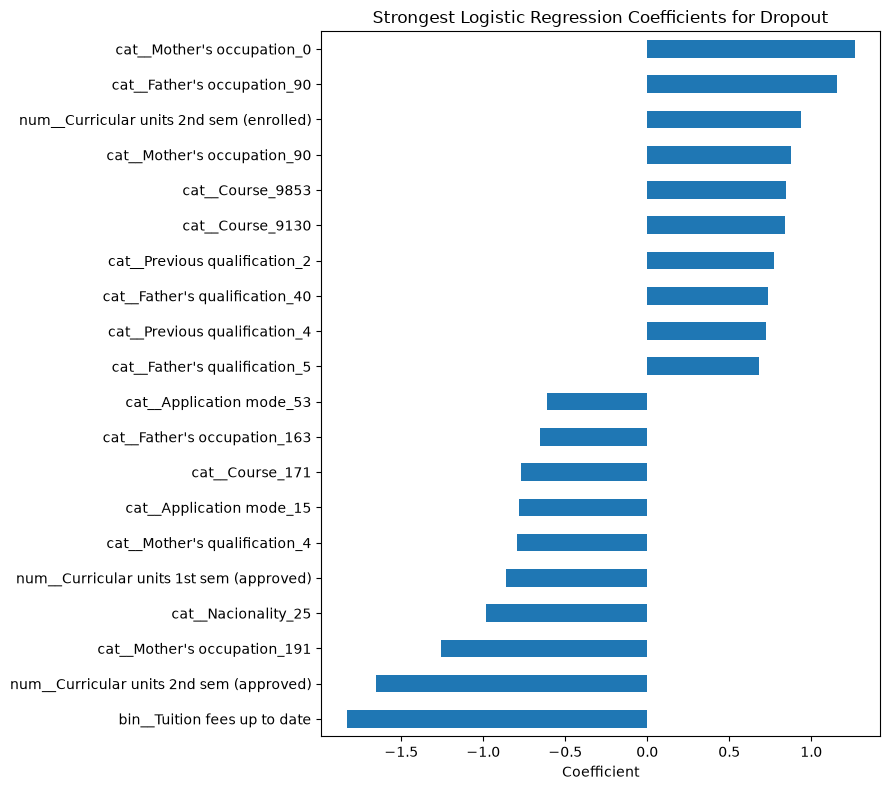

In [10]:
top_dropout_coef = pd.concat([dropout_coef.head(10), dropout_coef.tail(10)]).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
top_dropout_coef.plot(kind="barh", ax=ax)
ax.set_title("Strongest Logistic Regression Coefficients for Dropout")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()


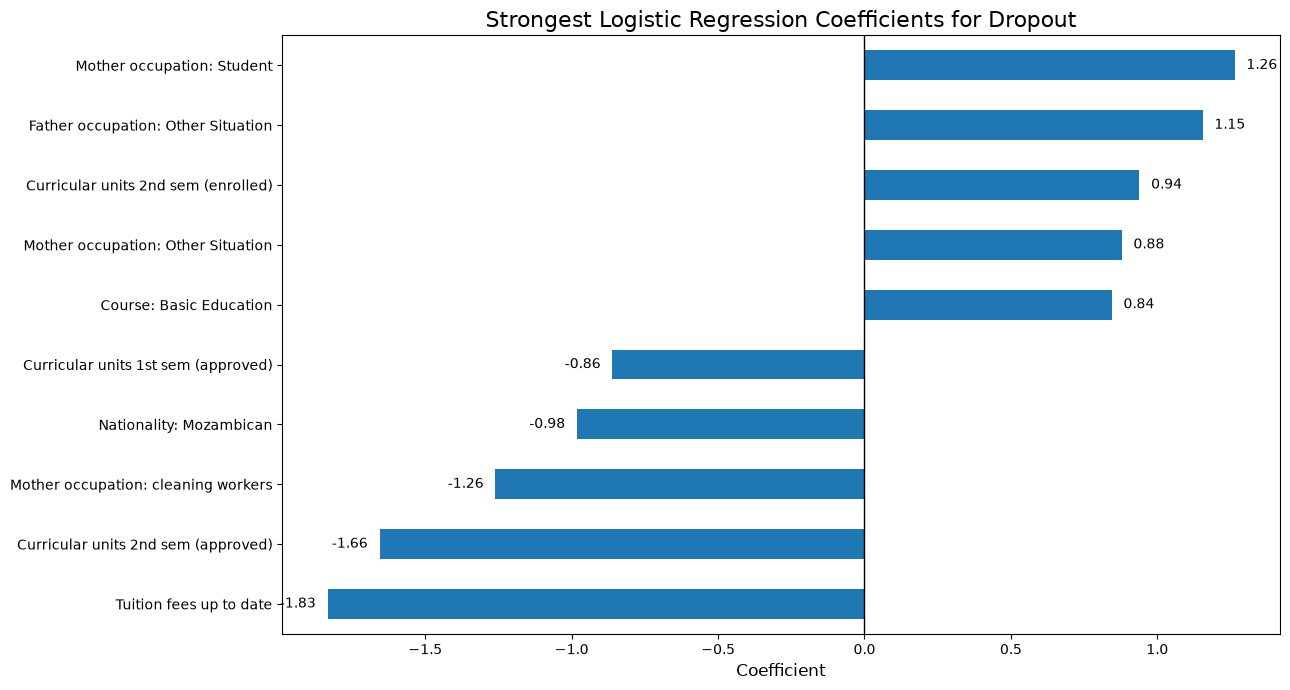

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import textwrap

# ==========================================================
# 1. Load the UCI variable table
# ==========================================================

variables = pd.read_csv("../data/raw/uci_variable_table.csv")

# ==========================================================
# 2. Convert UCI descriptions into code -> label dictionaries
# ==========================================================

def parse_codebook(description):
    """
    Converts a UCI description such as:
    '1 - Portuguese; 2 - German; ...'
    into:
    {1: 'Portuguese', 2: 'German', ...}
    """

    if pd.isna(description):
        return {}

    description = str(description)

    # Find every occurrence of:
    # integer code + " - "
    matches = list(re.finditer(r'(?<!\w)(\d+)\s*-\s*', description))

    mapping = {}

    for i, match in enumerate(matches):
        code = int(match.group(1))

        start = match.end()

        if i + 1 < len(matches):
            end = matches[i + 1].start()
        else:
            end = len(description)

        label = description[start:end]

        # Clean separators and whitespace
        label = label.strip(" ;,")
        label = re.sub(r"\s+", " ", label)

        mapping[code] = label

    return mapping


# Build one codebook for each UCI variable
codebooks = {}

for _, row in variables.iterrows():
    variable_name = row["name"]
    description = row["description"]

    codebooks[variable_name] = parse_codebook(description)


# ==========================================================
# 3. Translate transformed feature names into readable names
# ==========================================================

# Categorical variables that were one-hot encoded
categorical_variables = [
    "Marital status",
    "Application mode",
    "Course",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]


def readable_feature_name(feature):
    
    # --------------------------
    # Numeric features
    # --------------------------
    if feature.startswith("num__"):
        return feature.replace("num__", "")

    # --------------------------
    # Binary features
    # --------------------------
    if feature.startswith("bin__"):
        return feature.replace("bin__", "")

    # --------------------------
    # Categorical features
    # --------------------------
    if feature.startswith("cat__"):

        clean_feature = feature.replace("cat__", "")

        for variable in categorical_variables:

            prefix = variable + "_"

            if clean_feature.startswith(prefix):

                # Everything after the original variable name
                # is the category code
                code_string = clean_feature[len(prefix):]

                try:
                    code = int(code_string)
                except ValueError:
                    return clean_feature

                # Look up readable category
                category_label = codebooks.get(
                    variable, {}
                ).get(code, f"Code {code}")

                # Shorten a few variable names
                display_variable = {
                    "Mother's occupation": "Mother occupation",
                    "Father's occupation": "Father occupation",
                    "Mother's qualification": "Mother qualification",
                    "Father's qualification": "Father qualification",
                    "Previous qualification": "Previous qualification",
                    "Application mode": "Application mode",
                    "Nacionality": "Nationality",
                    "Marital status": "Marital status",
                    "Course": "Course"
                }.get(variable, variable)

                return f"{display_variable}: {category_label}"

    return feature


# ==========================================================
# 4. Select strongest individual coefficients
# ==========================================================

# Take the 10 largest coefficients by ABSOLUTE magnitude
n_features = 10

top_dropout = dropout_coef.loc[
    dropout_coef.abs().nlargest(n_features).index
].copy()

# Rename with readable UCI labels
top_dropout.index = [
    readable_feature_name(feature)
    for feature in top_dropout.index
]

# Sort by signed coefficient so negative -> positive
top_dropout = top_dropout.sort_values()


# ==========================================================
# 5. Shorten / wrap labels for presentation
# ==========================================================

wrapped_labels = [
    "\n".join(textwrap.wrap(label, width=42))
    for label in top_dropout.index
]

top_dropout.index = wrapped_labels


# ==========================================================
# 6. Plot signed coefficients
# ==========================================================

fig, ax = plt.subplots(figsize=(13, 7))

top_dropout.plot(
    kind="barh",
    ax=ax
)

# Zero reference line
ax.axvline(
    0,
    color="black",
    linewidth=1
)

ax.set_title(
    "Strongest Logistic Regression Coefficients for Dropout",
    fontsize=16
)

ax.set_xlabel(
    "Coefficient",
    fontsize=12
)

ax.set_ylabel("")

# Add coefficient values
for i, value in enumerate(top_dropout.values):

    if value < 0:
        ax.text(
            value - 0.04,
            i,
            f"{value:.2f}",
            va="center",
            ha="right",
            fontsize=10
        )

    else:
        ax.text(
            value + 0.04,
            i,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=10
        )

plt.tight_layout()

plt.savefig("dropout_coefficients_slide2.png", dpi=300, bbox_inches="tight")
plt.show()

Codes for variables table:

from ucimlrepo import fetch_ucirepo

# Fetch dataset
student_data = fetch_ucirepo(id=697)

# Variable metadata / codebook
variables = student_data.variables

variables.to_csv("uci_variable_table.csv", index=False)